# FAST-UAV - Fixed-Wing Design Optimization + Higher fidelidity aerodynamics
*Author: Félix Pollet - 2023* <br>
*Co-author: Fernando Urquía Cutillas - 2026* <br>

This notebook provides an example of design optimization of a fixed-wing UAV. The process is the same as the one for multirotor UAVs, except that some models and variables are different (e.g., for defining the wing geometry).

## 1. Setting up and analyzing the initial problem

In [1]:
# Import required librairies
import os.path as pth
import openmdao.api as om
import logging
import warnings
import shutil
import fastoad.api as oad
from time import time
import matplotlib.pyplot as plt
from fastuav.utils.postprocessing.analysis_and_plots import *

# Declare paths to folders and files
DATA_FOLDER_PATH = "./data"
WORK_FOLDER_PATH = "./workdir"
CONFIGURATION_FOLDER_PATH = pth.join(DATA_FOLDER_PATH, "configurations")
SOURCE_FOLDER_PATH = pth.join(DATA_FOLDER_PATH, "source_files")

CONFIGURATION_FILE = pth.join(CONFIGURATION_FOLDER_PATH, "fixedwing_mdo_NonPropu_Thin.yaml")

# SOURCE_FILE = pth.join(SOURCE_FOLDER_PATH, "problem_inputs_FW.xml")  # Source file provided for the example
SOURCE_FILE = pth.join(SOURCE_FOLDER_PATH, "problem_inputs_FMUC_NoPropu_Thin.xml")  # Source file provided for the example

# For having log messages display on screen
#logging.basicConfig(level=logging.INFO, format="%(levelname)-8s: %(message)s")
#warnings.filterwarnings(action="ignore")

# For using all screen width
from IPython.display import display, HTML, IFrame
display(HTML("<style>.container { width:95% !important; }</style>"))

As you can see in the following N2 diagram, some models used for the fixed-wing UAV are (obviously) different from the multirotor ones. Have a look at the geometry discipline. The arms and body frame have been replaced by wings, tails, and a fuselage. The aerodynamics module also includes models for estimating the parasitic drag, among others.


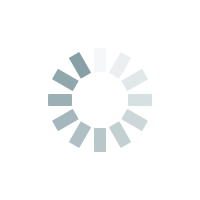
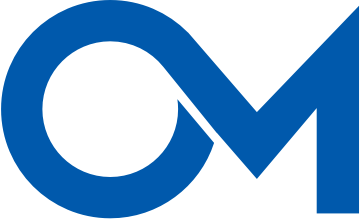
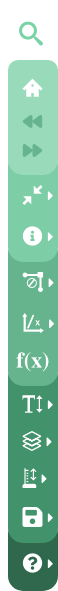

In [2]:
import html
import webbrowser
N2_FILE = pth.join(WORK_FOLDER_PATH, "n2_fixed-wing.html")

# Display the N2 file (works in VSCode notebooks)
# 1. Generate the N2 file as an .HTML file
oad.write_n2(CONFIGURATION_FILE, N2_FILE, overwrite=True)
# 2. Read the generated HTML into a string
with open(N2_FILE, 'r', encoding='utf-8') as f:
    html_content = f.read()
escaped_html = html.escape(html_content)  # Escape the HTML so it can be safely embedded

# 3. Display using an IFrame with 'srcdoc' instead of 'src'
iframe_code = f"""
<iframe width="100%" height="600px" style="border: none;" srcdoc="{escaped_html}"></iframe>
"""
display(HTML(iframe_code))


# Display the N2 file in an IFrame (works in Jupyter notebooks)
# from IPython.display import IFrame
# display(IFrame(src=N2_FILE, width="100%", height="500px"))

# Display the N2 file in a new browser tab
# webbrowser.open_new_tab(N2_FILE)

Also another useful tool is to visualize the XDSM diagram

In [3]:
# XDSM_FILE = pth.join(WORK_FOLDER_PATH, "xdsm.html")
# oad.write_xdsm(CONFIGURATION_FILE, XDSM_FILE, overwrite=True)

# # 2. Read the generated HTML into a string
# with open(XDSM_FILE, 'r', encoding='utf-8') as f:
#     html_content = f.read()
# escaped_html = html.escape(html_content)  # Escape the HTML so it can be safely embedded

# # 3. Display using an IFrame with 'srcdoc' instead of 'src'
# iframe_code = f"""
# <iframe width="100%" height="600px" style="border: none;" srcdoc="{escaped_html}"></iframe>
# """
# display(HTML(iframe_code))

# # IFrame(src=XDSM_FILE, width="100%", height="500px")

Once again, we generate a temporary input file for this notebook, so that the reference source file cannot be corrupted:

In [4]:
oad.generate_inputs(CONFIGURATION_FILE, SOURCE_FILE, overwrite=True)

'C:/Users/STEALTH/Documents/VSCodeProjects/FORKS/FAST-UAV_FMUC/src/fastuav/notebooks/workdir/problem_inputs_FMUC.xml'

The [problem_inputs.xml](./workdir/problem_inputs.xml) file now includes parameters such as the material properties for the spars and the ribs of the wing. Take your time to check these parameters specific to fixed-wing UAVs.

In [5]:
INPUT_FILE = pth.join(WORK_FOLDER_PATH, "problem_inputs_FMUC.xml")
oad.variable_viewer(INPUT_FILE)

## 2. Running an MDO

You can now run an optimization problem. Here again, some design variables and constraints defined in the [configuration file](./data/configurations/fixedwing_mdo.yaml) are specific to fixed-wing UAVs. For example:

```yaml
optimization:
  design_variables:
    - name: optimization:variables:geometry:wing:loading:k  # under estimation coefficient on the wing loading
      lower: 0.1
      upper: 1.0
    - name: optimization:variables:geometry:wing:AR  # aspect ratio of the wing
      lower: 8.0
      upper: 20.0
  constraints:
    - name: optimization:constraints:geometry:fuselage:volume  # fuselage volume requirement (to carry the batteries and the payload)
      lower: 0.0
```

In [6]:
# optim_problem = oad.optimize_problem(CONFIGURATION_FILE, overwrite=True)
from fastuav.utils.optim_iteration_logger import optimize_problem_with_logging, plot_iteration_log

optim_problem, log_df = optimize_problem_with_logging(
    CONFIGURATION_FILE,
    log_path="./workdir/optim_log.csv",
    overwrite=True,
)

[logger] 11 design vars, 7 constraints, 1 objectives
[logger] XML snapshot enabled — C:\Users\STEALTH\Documents\VSCodeProjects\FORKS\FAST-UAV_FMUC\src\fastuav\notebooks\workdir\problem_outputs_FMUC.xml will be overwritten after every iteration
[logger] Running optimisation, recording to c:\Users\STEALTH\Documents\VSCodeProjects\FORKS\FAST-UAV_FMUC\src\fastuav\notebooks\workdir\optim_log_cases.sql
[snapshot] iter 1: wrote C:\Users\STEALTH\Documents\VSCodeProjects\FORKS\FAST-UAV_FMUC\src\fastuav\notebooks\workdir\problem_outputs_FMUC.xml

[logger] *** Interrupted by user (Ctrl+C) ***
[logger]   Saving last state to XML and CSV...
[logger] Driver finished in 60.57s — status: INTERRUPTED
[logger] Wrote outputs to: C:\Users\STEALTH\Documents\VSCodeProjects\FORKS\FAST-UAV_FMUC\src\fastuav\notebooks\workdir\problem_outputs_FMUC.xml
[snapshot] 7 XML snapshots written to C:\Users\STEALTH\Documents\VSCodeProjects\FORKS\FAST-UAV_FMUC\src\fastuav\notebooks\workdir\problem_outputs_FMUC.xml
[logger]

In [8]:
# fig = plot_iteration_log("./workdir/optim_log.csv")
# fig.show()
from fastuav.utils.sql_to_csv import sql_to_csv

df = sql_to_csv(
    "./workdir/optim_log_cases.sql",
    "./workdir/optim_log.csv",
    configuration_file="./data/configurations/fixedwing_mdo_NonPropu_Thin.yaml",
)
df.tail()

from fastuav.utils.optim_iteration_logger import (
    optimize_problem_with_logging,
    plot_iteration_log_interactive,
)

# ... run optimization as before ...

# Interactive version (returns a plotly figure):
fig = plot_iteration_log_interactive("./workdir/optim_log.csv")
fig.show()


[sql->csv] 7 cases in ./workdir/optim_log_cases.sql
[sql->csv] YAML: 11 DVs, 7 constraints, 1 obj
[sql->csv] Wrote 7 rows x 20 cols -> ./workdir/optim_log.csv


In [ ]:
from fastoad.io.configuration import FASTOADProblemConfigurator

# After optimization finishes (even if it reports FAILED):
config_file = "data/configurations/fixedwing_mdo_NonPropu_Thin.yaml"
output_file = "workdir/problem_outputs_FMUC.xml"

configurator = FASTOADProblemConfigurator(config_file)
problem = configurator.get_problem()

# Load the current state (from the last optimizer iteration)
# The problem object should already have the final design from the run
problem.write_outputs("workdir/problem_outputs_FMUC.xml")


print(f"Output written to {output_file}")

TypeError: FASTOADProblem.write_outputs() takes 1 positional argument but 2 were given

Let's save and visualize these results:

In [ ]:
import os.path as pth
DATA_FOLDER_PATH = "./data"
WORK_FOLDER_PATH = "./workdir"
CONFIGURATION_FOLDER_PATH = pth.join(DATA_FOLDER_PATH, "configurations")
SOURCE_FOLDER_PATH = pth.join(DATA_FOLDER_PATH, "source_files")

# FW_OUTPUT_FILE = pth.join(SOURCE_FOLDER_PATH, 'problem_outputs_FW_mdo.xml')
# shutil.copy(OUTPUT_FILE, FW_OUTPUT_FILE)

In [ ]:
oad.optimization_viewer(CONFIGURATION_FILE)

c:\Users\STEALTH\AppData\Local\pypoetry\Cache\virtualenvs\fastuav-WnZBHFRY-py3.10\lib\site-packages\jupyter_client\session.py:727: UserWarning:

Message serialization failed with:
Out of range float values are not JSON compliant
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant



In [ ]:
oad.variable_viewer(OUTPUT_FILE)

## 3. Analysis and plots

You can now use postprocessing plots to visualize the results of the MDO.

In [ ]:
fig = fixedwing_geometry_plot(OUTPUT_FILE,name="VLM CDi geometry")
# fig = fixedwing_geometry_plot(pth.join(WORK_FOLDER_PATH, "problem_outputs.xml"), name="Raymer's CDi geometry",fig=fig)
fig = fixedwing_geometry_plot(pth.join(WORK_FOLDER_PATH, "problem_outputs_FMUC_smaller_density.xml"), name="VLM CDi geometry + Smaller density",fig=fig)
fig.show()

In [ ]:
fig = mass_breakdown_sun_plot_drone(OUTPUT_FILE)
fig.show()